In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

**Đọc ảnh từ Drive**

Đổi image_path.

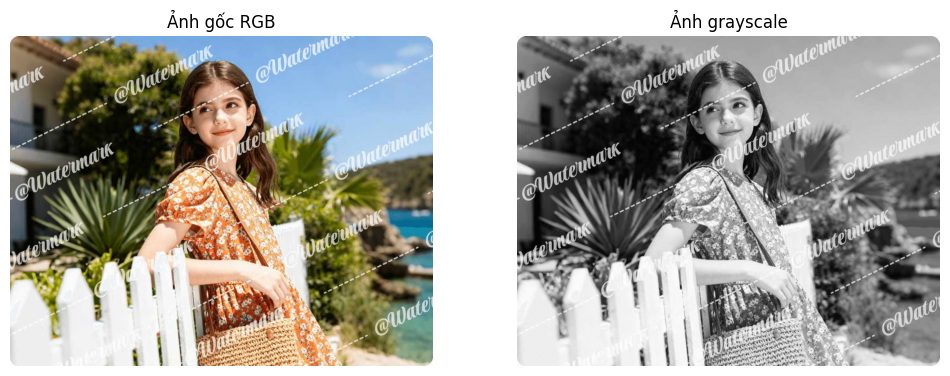

In [19]:
image_path = "/content/drive/MyDrive/Colab/CPV301/dataset/image_3.jpg"

img_bgr = cv2.imread(image_path)

if img_bgr is None:
    raise FileNotFoundError("Không đọc được ảnh. Kiểm tra lại image_path.")

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Ảnh gốc RGB")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_gray, cmap="gray")
plt.title("Ảnh grayscale")
plt.axis("off")

plt.show()

**Step 1: Chuyển ảnh sang miền tần số bằng FFT**

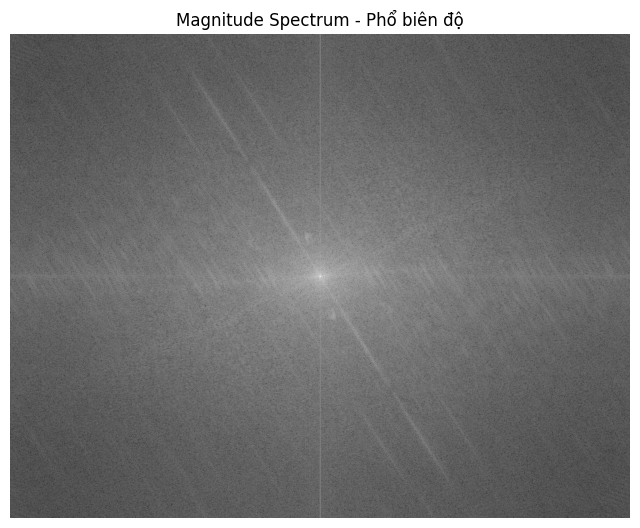

In [20]:
# FFT 2D
f = np.fft.fft2(img_gray)

# Đưa tần số thấp về giữa ảnh
fshift = np.fft.fftshift(f)

# Phổ biên độ
magnitude_spectrum = 20 * np.log(np.abs(fshift) + 1)

plt.figure(figsize=(8, 8))
plt.imshow(magnitude_spectrum, cmap="gray")
plt.title("Magnitude Spectrum - Phổ biên độ")
plt.axis("off")
plt.show()

Cell này giúp tăng tương phản phổ Fourier để dễ nhìn điểm bất thường.

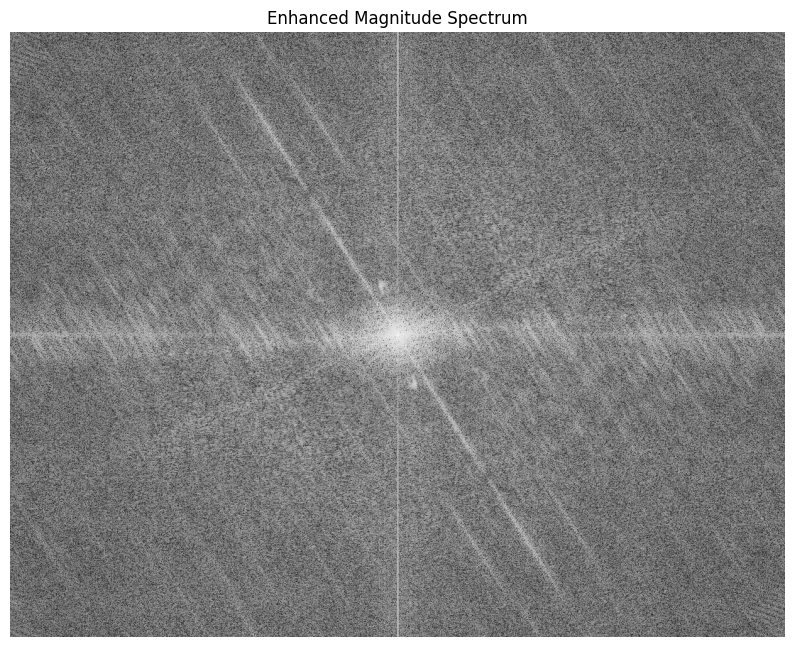

In [21]:
mag_norm = cv2.normalize(magnitude_spectrum, None, 0, 255, cv2.NORM_MINMAX)
mag_norm = mag_norm.astype(np.uint8)

# Tăng tương phản bằng CLAHE
clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
mag_enhanced = clahe.apply(mag_norm)

plt.figure(figsize=(10, 10))
plt.imshow(mag_enhanced, cmap="gray")
plt.title("Enhanced Magnitude Spectrum")
plt.axis("off")
plt.show()

**Step 2: Tạo notch filter thủ công**

Cần chỉnh các điểm trong **notch_points** dựa trên phổ Fourier ở cell trước.

Lưu ý: tọa độ ảnh là (x, y), trong đó:

- x: chiều ngang
- y: chiều dọc

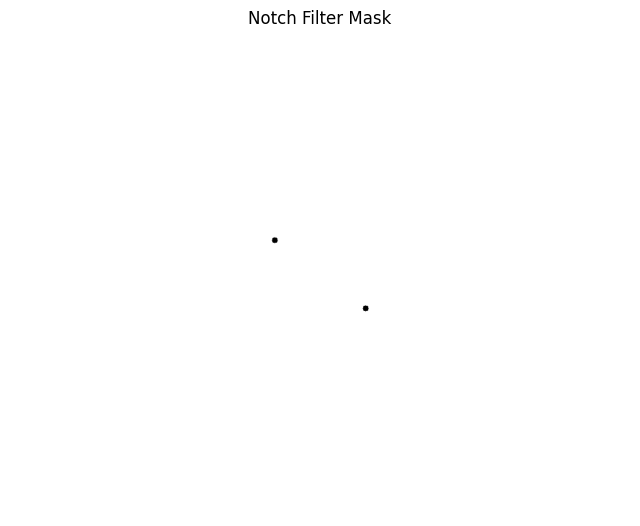

In [30]:
rows, cols = img_gray.shape
crow, ccol = rows // 2, cols // 2

# Mask ban đầu: cho toàn bộ tần số đi qua
mask = np.ones((rows, cols), dtype=np.float32)

# Các điểm cần lọc trong phổ tần số
# Hãy chỉnh các tọa độ này theo ảnh của bạn
notch_points = [
    (ccol + 80, crow + 60),
    (ccol - 80, crow - 60),
]

radius = 5

for x, y in notch_points:
    cv2.circle(mask, (x, y), radius, 0, -1)

plt.figure(figsize=(8, 8))
plt.imshow(mask, cmap="gray")
plt.title("Notch Filter Mask")
plt.axis("off")
plt.show()

**Step 3: Áp dụng notch filter vào phổ Fourier**

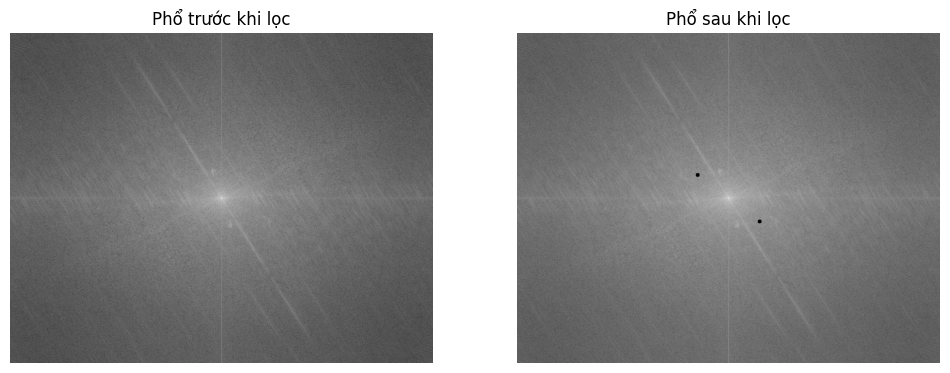

In [31]:
fshift_filtered = fshift * mask

magnitude_filtered = 20 * np.log(np.abs(fshift_filtered) + 1)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(magnitude_spectrum, cmap="gray")
plt.title("Phổ trước khi lọc")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(magnitude_filtered, cmap="gray")
plt.title("Phổ sau khi lọc")
plt.axis("off")

plt.show()

**Step 4: Inverse FFT để đưa ảnh về miền không gian**

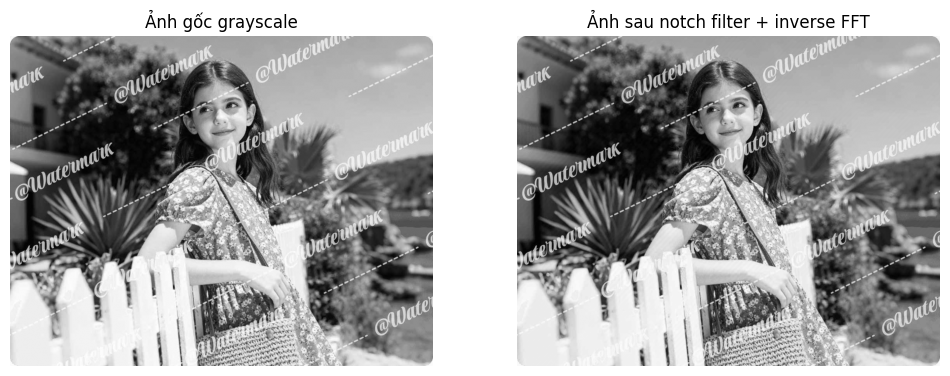

In [27]:
# Đưa tần số thấp về lại góc ảnh
f_ishift = np.fft.ifftshift(fshift_filtered)

# Inverse FFT
img_back = np.fft.ifft2(f_ishift)
img_back = np.abs(img_back)

# Chuẩn hóa về 0-255
img_back_norm = cv2.normalize(img_back, None, 0, 255, cv2.NORM_MINMAX)
img_back_norm = img_back_norm.astype(np.uint8)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap="gray")
plt.title("Ảnh gốc grayscale")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_back_norm, cmap="gray")
plt.title("Ảnh sau notch filter + inverse FFT")
plt.axis("off")

plt.show()